# Main Figure Revision Sandbox

This notebook is a separate workspace for the requested figure edits without changing `make_main_figures_outline_v2.ipynb`.

Revision targets captured here:

- Figure 2: grouped PCA plus repeated RF separability violin panels by dataset.
- Figure 4: replace cognitively heavy correlation-preservation panels with simple all-dataset summaries of feature-pair correlation change.
- Figure 5: keep the existing noise plot direction.
- Figure 6: combine HIV, breast cancer, and diabetes reverse-ablation curves into one figure.
- Figure 1 schematic: source appears to be Matplotlib code, not a PowerPoint/Keynote file or GPT image. See the final schematic notes cell for editable options.


## Load Shared Definitions

This cell imports definitions from the outline notebook without running the expensive plotting/compute calls at the bottom of those cells. It also forces `RUN_MODE = "preview"` by default for quick iteration. Switch `REVISION_RUN_MODE` to `"final"` when you want manuscript-quality repeated runs.


In [ ]:
from pathlib import Path
import json
import pickle
import re

REVISION_RUN_MODE = "final" 
OUTLINE_NOTEBOOK = Path("data_synthesis/notebooks/make_main_figures_outline_v2.ipynb")


def _find_repo_root():
    here = Path.cwd().resolve()
    candidates = [here, *here.parents]
    for candidate in candidates:
        if (candidate / OUTLINE_NOTEBOOK).exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find {OUTLINE_NOTEBOOK} from {here}. "
        "Run this notebook from the repository or update OUTLINE_NOTEBOOK."
    )


repo_root = _find_repo_root()
outline_path = repo_root / OUTLINE_NOTEBOOK
CACHE_DIR = repo_root / "data_synthesis" / "notebooks" / "revision_cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)


def _trim_source(src, stop_patterns):
    lines = src.splitlines()
    kept = []
    for line in lines:
        if any(re.search(pattern, line) for pattern in stop_patterns):
            break
        kept.append(line)
    return "\n".join(kept) + "\n"


def _pick_code_cell(code_cells, startswith):
    for src in code_cells:
        if src.lstrip().startswith(startswith):
            return src
    raise KeyError(f"Could not find outline code cell starting with: {startswith}")


def _find_code_cell(code_cells, text):
    for src in code_cells:
        if text in src:
            return src
    raise KeyError(f"Could not find outline code cell containing: {text}")


def load_outline_definitions(run_mode=REVISION_RUN_MODE):
    nb = json.loads(outline_path.read_text(encoding="utf-8"))
    code_cells = ["".join(cell.get("source", [])) for cell in nb["cells"] if cell.get("cell_type") == "code"]

    selected = []
    setup = _pick_code_cell(code_cells, "from pathlib import Path")
    selected.append(setup.replace('RUN_MODE = "final"', f'RUN_MODE = "{run_mode}"'))
    selected.append(_pick_code_cell(code_cells, "def _to_numpy_X"))
    selected.append(_trim_source(_pick_code_cell(code_cells, "def plot_figure2_cvae_pca"), [r"^plot_figure2_cvae_pca\("]))
    selected.append(_trim_source(_pick_code_cell(code_cells, "def one_run_origin_auc"), [r"^auc_runs\s*="]))
    selected.append(_trim_source(_pick_code_cell(code_cells, "def mean_kld_by_feature"), [r"^metric_table\s*="]))
    selected.append(_trim_source(_pick_code_cell(code_cells, "def feature_group"), [r"^plot_figure4_structure_panel\("]))
    selected.append(_trim_source(_pick_code_cell(code_cells, "def rank_discriminating_features"), [r"^ablation_df\s*="]))
    selected.append(_trim_source(_find_code_cell(code_cells, "def plot_figure6_ablation_ac"), [r"^if \"ablation_df\" in globals\(\):"]))

    g = globals()
    for src in selected:
        exec(compile(src, str(outline_path), "exec"), g)

    # The imported setup cell defines its own repo_root based on the kernel cwd.
    # Restore the robust root found above so later export/cache paths are stable.
    g["repo_root"] = repo_root


load_outline_definitions()
print(f"Loaded outline definitions from {outline_path}")
print(f"Revision run mode: {RUN_MODE}; CVAE_EPOCHS={CVAE_EPOCHS}; AUC_REPEATS={AUC_REPEATS}; ABLATION_REPEATS={ABLATION_REPEATS}")
print(summary)


Repository root: c:\Users\tonyt\Desktop\distinguishable_data
Run mode: final | CVAE_EPOCHS=200, AUC_REPEATS=50, TSTR_REPEATS=20, ABLATION_REPEATS=20, NOISE_REPEATS=5
Loaded outline definitions from C:\Users\tonyt\Desktop\distinguishable_data\data_synthesis\notebooks\make_main_figures_outline_v2.ipynb
Revision run mode: final; CVAE_EPOCHS=200; AUC_REPEATS=50; ABLATION_REPEATS=20
         dataset  samples  features  class_0  class_1
0            HIV       91        63       23       68
1  Breast Cancer      569        30      212      357
2       Diabetes      768         8      500      268


## Cached Compute Helpers

These wrappers avoid recomputing repeated RF probes, correlation summaries, and reverse ablation every time the notebook is opened. Set `force=True` in any helper call to regenerate.


In [68]:
def _cache_path(name):
    return CACHE_DIR / f"{name}_{RUN_MODE}.pkl"


def _read_cache(name):
    path = _cache_path(name)
    if path.exists():
        with path.open("rb") as f:
            return pickle.load(f)
    return None


def _write_cache(name, obj):
    path = _cache_path(name)
    with path.open("wb") as f:
        pickle.dump(obj, f)
    return obj


def get_auc_runs(force=False):
    cached = None if force else _read_cache("auc_runs")
    if cached is not None:
        return cached
    return _write_cache("auc_runs", compute_auc_run_table(datasets))


def get_metric_table(force=False):
    cached = None if force else _read_cache("metric_table")
    if cached is not None:
        return cached
    auc_runs = get_auc_runs(force=force)
    return _write_cache("metric_table", build_metric_table(datasets, auc_runs))


def get_reverse_ablation(force=False):
    cached = None if force else _read_cache("ablation_df")
    if cached is not None:
        return cached
    return _write_cache("ablation_df", compute_reverse_ablation(datasets))


## Figure 2 Decision Note

The boxplot version is omitted here. Figure 2 uses the PCA panels plus the repeated RF separability violin panels, because the violins show the full repeated-run distribution while keeping the dataset-level story compact.

The default is a grouped 6-panel Figure 2, arranged by dataset:

- HIV column: PCA geometry + repeated RF separability violin.
- Breast Cancer column: PCA geometry + repeated RF separability violin.
- Diabetes column: PCA geometry + repeated RF separability violin.

Vertical dividers separate the dataset groups so each PCA/separability pair reads as one unit.


In [69]:
def _plot_pca_panel(ax, ds, panel, seed=SEED, cvae_epochs=CVAE_EPOCHS):
    data = datasets[ds]
    X_real = np.asarray(data["X"], dtype=np.float32)
    X_syn, _ = sample_synthetic(ds, data, "CVAE", seed=seed, cvae_epochs=cvae_epochs)
    Xr, Xs = standardize_pair(X_real, X_syn)
    pca = PCA(n_components=2, random_state=seed).fit(Xr)
    Zr = pca.transform(Xr)
    Zs = pca.transform(Xs)
    rng = np.random.default_rng(seed)
    Zs_plot = Zs[rng.choice(len(Zs), size=700, replace=False)] if len(Zs) > 700 else Zs

    ax.scatter(Zr[:, 0], Zr[:, 1], s=8, marker="o", facecolors="none", alpha=0.58,
               edgecolors="#8A8A8A", linewidths=0.55, label="Real data")
    ax.scatter(Zs_plot[:, 0], Zs_plot[:, 1], s=8, marker="o", color=DATASET_COLORS[ds], alpha=0.74,
               edgecolors="none", label="CVAE synthetic data")
    add_confidence_ellipse(ax, Zr, "#8A8A8A", linewidth=1.8)
    add_confidence_ellipse(ax, Zs, DATASET_COLORS[ds], linewidth=2.0)

    all_z = np.vstack([Zr, Zs_plot])
    x_min, x_max = np.nanmin(all_z[:, 0]), np.nanmax(all_z[:, 0])
    y_min, y_max = np.nanmin(all_z[:, 1]), np.nanmax(all_z[:, 1])
    ax.set_xlim(x_min - (x_max - x_min) * 0.24, x_max + (x_max - x_min) * 0.24)
    ax.set_ylim(y_min - (y_max - y_min) * 0.24, y_max + (y_max - y_min) * 0.24)

    ev = pca.explained_variance_ratio_
    ax.set_title(ds, color=DATASET_COLORS[ds], weight="semibold", pad=8)
    ax.set_xlabel(f"PC1 ({ev[0] * 100:.1f}%)")
    ax.set_ylabel(f"PC2 ({ev[1] * 100:.1f}%)")
    ax.text(0.045, 0.055, f"n={len(data['y'])}, p={X_real.shape[1]}", transform=ax.transAxes,
            color=DATASET_COLORS[ds], fontsize=8.5, weight="bold", ha="left", va="bottom")
    ax.legend(loc="upper left", frameon=True, facecolor="white", edgecolor="#BDBDBD",
              framealpha=0.92, fontsize=7.8, handlelength=1.2, borderpad=0.35,
              labelspacing=0.25, handletextpad=0.35)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.2)
    ax.tick_params(labelsize=8.5, width=1.2, length=4)
    add_panel_label(ax, panel)


def _plot_auc_violin_panel(ax, auc_runs, ds, panel):
    sub = auc_runs[auc_runs["dataset"] == ds]
    positions = np.arange(len(METHOD_ORDER))
    values = [sub[sub["method"] == method]["separability_auc"].dropna().to_numpy() for method in METHOD_ORDER]

    violins = ax.violinplot(values, positions=positions, widths=0.72, showmeans=False, showmedians=False, showextrema=False)
    for body, method in zip(violins["bodies"], METHOD_ORDER):
        body.set_facecolor(METHOD_PASTELS[method])
        body.set_edgecolor(METHOD_COLORS[method])
        body.set_linewidth(1.45)
        body.set_alpha(0.95)

    for pos, vals, method in zip(positions, values, METHOD_ORDER):
        vals = np.asarray(vals, dtype=float)
        if len(vals) == 0:
            continue
        q1, med, q3 = np.percentile(vals, [25, 50, 75])
        mean = np.mean(vals)
        ax.vlines(pos, q1, q3, color=METHOD_COLORS[method], linewidth=3.0, alpha=0.92)
        ax.scatter(pos, med, s=28, color="white", edgecolor=METHOD_COLORS[method], linewidth=1.3, zorder=4)
        ax.scatter(pos, mean, s=22, color=METHOD_COLORS[method], edgecolor="white", linewidth=0.7, zorder=5)

    ax.axhline(0.5, color="#777777", linestyle="--", linewidth=1.2)
    ax.set_xticks(positions)
    ax.set_xticklabels(METHOD_ORDER, rotation=25, ha="right", fontsize=8.5)
    ax.set_ylabel("AUC")
    clean_axis(ax, grid_axis="y")
    add_panel_label(ax, panel)


def _plot_auc_line_panel(ax, auc_runs, ds, panel):
    sub = auc_runs[auc_runs["dataset"] == ds]
    means = sub.groupby("method")["separability_auc"].mean().reindex(METHOD_ORDER)
    sds = sub.groupby("method")["separability_auc"].std().reindex(METHOD_ORDER)
    x = np.arange(len(METHOD_ORDER))
    for i, method in enumerate(METHOD_ORDER):
        ax.errorbar(i, means.loc[method], yerr=sds.loc[method], marker="o", markersize=7,
                    color=METHOD_COLORS[method], capsize=4, linewidth=2.0)
    ax.plot(x, means.to_numpy(), color=DATASET_COLORS[ds], linewidth=2.0, alpha=0.65)
    ax.axhline(0.5, color="#777777", linestyle="--", linewidth=1.2)
    ax.set_xticks(x)
    ax.set_xticklabels(METHOD_ORDER, rotation=25, ha="right", fontsize=8.5)
    ax.set_title(f"{ds}: mean +/- SD", color=DATASET_COLORS[ds], weight="bold", pad=8)
    ax.set_ylabel("AUC")
    clean_axis(ax, grid_axis="y")
    add_panel_label(ax, panel)


def plot_figure2_six_panel(auc_runs):
    fig, axes = plt.subplots(2, 3, figsize=(13.8, 8.2))
    panel_labels = [("A", "B"), ("C", "D"), ("E", "F")]

    for col, ds in enumerate(DATASET_ORDER):
        pca_ax = axes[0, col]
        sep_ax = axes[1, col]
        _plot_pca_panel(pca_ax, ds, panel_labels[col][0])
        _plot_auc_violin_panel(sep_ax, auc_runs, ds, panel_labels[col][1])

        # Use one dataset header per column, so each PCA/separability pair reads as a unit.
        pca_ax.set_title("")
        sep_ax.set_title("RF separability", color=NEUTRAL, weight="semibold", pad=8, fontsize=12.0)

    fig.suptitle("Synthetic data geometry and separability by dataset", y=0.99, fontsize=15, weight="semibold")
    fig.subplots_adjust(left=0.065, right=0.99, top=0.83, bottom=0.10, wspace=0.34, hspace=0.38)

    for col, ds in enumerate(DATASET_ORDER):
        # Compute after subplots_adjust so the header is centered over the final column position.
        top_box = axes[0, col].get_position()
        x_center = (top_box.x0 + top_box.x1) / 2
        fig.text(
            x_center,
            0.845,
            ds,
            ha="center",
            va="bottom",
            fontsize=13.5,
            weight="bold",
            color=DATASET_COLORS[ds],
        )

    # Vertical dividers emphasize the three dataset groups.
    for left_ax, right_ax in zip(axes[0, :-1], axes[0, 1:]):
        left_box = left_ax.get_position()
        right_box = right_ax.get_position()
        x_sep = (left_box.x1 + right_box.x0) / 2
        fig.add_artist(mpl.lines.Line2D(
            [x_sep, x_sep],
            [0.10, 0.84],
            transform=fig.transFigure,
            color="#D0D0D0",
            linewidth=1.0,
            alpha=0.9,
        ))
    return fig


def plot_figure2_nine_panel(auc_runs):
    fig, axes = plt.subplots(3, 3, figsize=(13.8, 11.4))
    panels = list("ABCDEFGHI")
    for ax, ds, panel in zip(axes[0], DATASET_ORDER, panels[:3]):
        _plot_pca_panel(ax, ds, panel)
    for ax, ds, panel in zip(axes[1], DATASET_ORDER, panels[3:6]):
        _plot_auc_violin_panel(ax, auc_runs, ds, panel)
    for ax, ds, panel in zip(axes[2], DATASET_ORDER, panels[6:]):
        _plot_auc_line_panel(ax, auc_runs, ds, panel)
    fig.suptitle("Figure 2. PCA geometry, separability distributions, and summary trends", y=0.99, fontsize=15, weight="semibold")
    fig.subplots_adjust(left=0.065, right=0.99, top=0.94, bottom=0.08, wspace=0.30, hspace=0.50)
    return fig


Epoch    1 | train loss=62.4155 recon=62.3285 kl=0.1739 | val loss=78.0305 recon=77.9509 kl=0.1592


Epoch   10 | train loss=60.2981 recon=59.3696 kl=1.8570 | val loss=73.8223 recon=72.3963 kl=2.8520
Epoch   20 | train loss=45.2113 recon=42.3136 kl=5.7955 | val loss=57.2817 recon=54.6984 kl=5.1666
Epoch   30 | train loss=42.0345 recon=39.7095 kl=4.6499 | val loss=55.0446 recon=51.7816 kl=6.5261
Epoch   40 | train loss=33.0294 recon=28.9220 kl=8.2147 | val loss=50.6568 recon=45.6760 kl=9.9616
Epoch   50 | train loss=31.2742 recon=28.0664 kl=6.4157 | val loss=48.5147 recon=44.3200 kl=8.3894
Epoch   60 | train loss=32.8561 recon=28.8008 kl=8.1105 | val loss=49.1238 recon=44.7974 kl=8.6528
Epoch   70 | train loss=30.9240 recon=26.7437 kl=8.3607 | val loss=47.6689 recon=43.4627 kl=8.4124
Epoch   80 | train loss=27.9926 recon=24.0453 kl=7.8946 | val loss=47.8886 recon=43.1245 kl=9.5281
Epoch   90 | train loss=29.5343 recon=23.9421 kl=11.1845 | val loss=46.2952 recon=41.3053 kl=9.9797
Epoch  100 | train loss=26.4184 recon=21.9669 kl=8.9031 | val loss=48.0467 recon=43.2697 kl=9.5540
Epoch  11

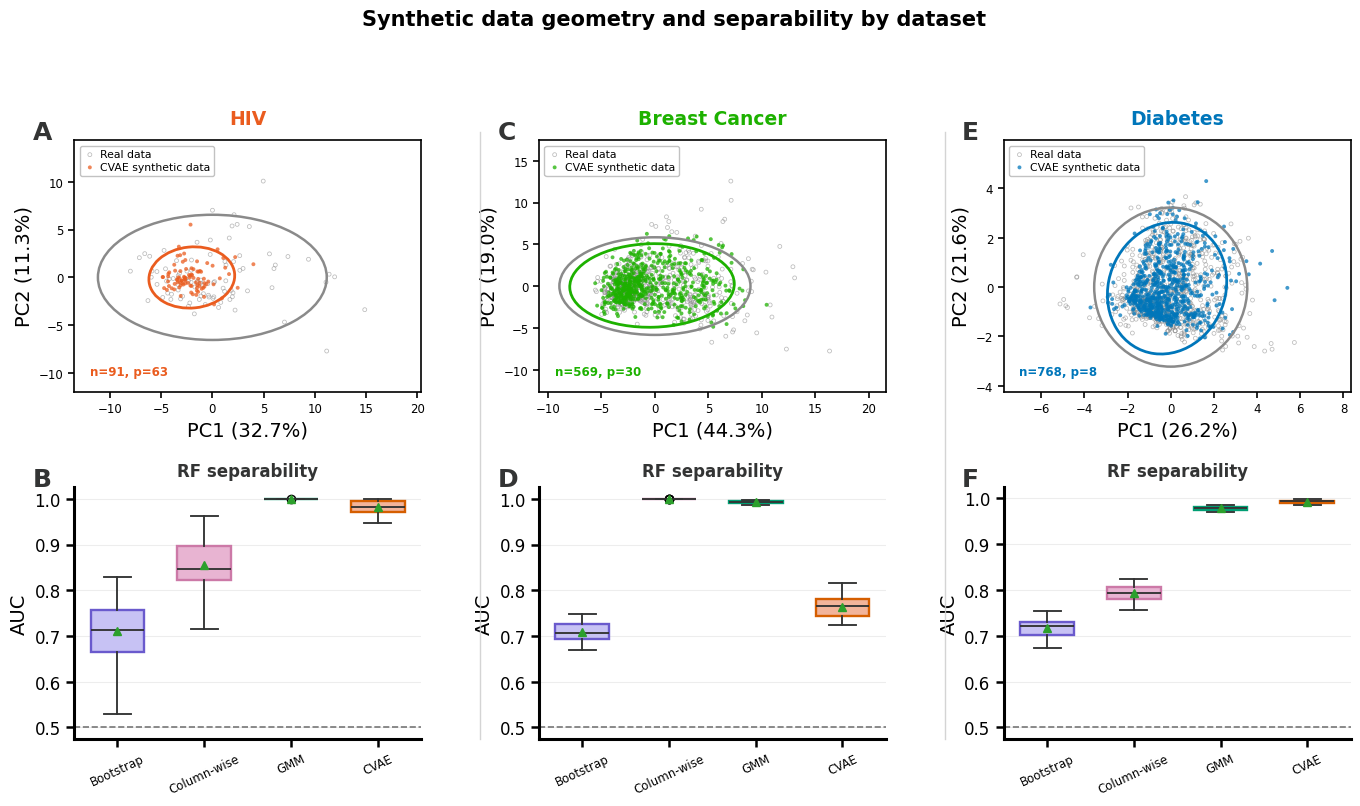

In [70]:
auc_runs = get_auc_runs(force=False)
fig2_6 = plot_figure2_six_panel(auc_runs)
# fig2_9 = plot_figure2_nine_panel(auc_runs)


## Figure 4: Correlation Change

Question: do synthetic datasets keep the same relationships between features as the real dataset?

For every pair of features, we compute one correlation in the real data and one correlation in the synthetic data. Then we ask how far apart those two correlations are:

`correlation change = |real correlation - synthetic correlation|`

Example: if two features have correlation `0.70` in real data and `0.45` in synthetic data, the change is `|0.70 - 0.45| = 0.25`.

Main readout:

- **A. Average correlation change**: average change across all feature pairs. Lower is better.
- **B. Pairs with large change**: percent of feature pairs where change is greater than `0.10`. Lower is better.
- **C. Worst-case change**: the 90th percentile of feature-pair changes. Lower is better.

So darker/more intense cells mean the synthetic method changed real feature relationships more. The diagnostic table below lists which feature pairs changed most.


In [71]:
def feature_correlation_change_scores(real_corr, syn_corr, feature_names):
    change = np.abs(real_corr - syn_corr).astype(float)
    np.fill_diagonal(change, np.nan)
    scores = np.nanmean(change, axis=1)
    return pd.DataFrame({"feature": feature_names, "avg_correlation_change": scores}).sort_values(
        "avg_correlation_change", ascending=False
    )


def top_changed_correlation_pairs(real_corr, syn_corr, feature_names, top_n=8):
    rows = []
    for i in range(len(feature_names)):
        for j in range(i + 1, len(feature_names)):
            real_val = float(real_corr[i, j])
            syn_val = float(syn_corr[i, j])
            rows.append({
                "feature_1": feature_names[i],
                "feature_2": feature_names[j],
                "real_corr": real_val,
                "synthetic_corr": syn_val,
                "correlation_change": abs(real_val - syn_val),
            })
    return pd.DataFrame(rows).sort_values("correlation_change", ascending=False).head(top_n)


def compute_correlation_preservation(datasets, seed=SEED, cvae_epochs=CVAE_EPOCHS, large_change_cutoff=0.10):
    rows = []
    feature_rows = []
    pair_rows = []
    for ds in DATASET_ORDER:
        data = datasets[ds]
        X_real = np.asarray(data["X"], dtype=np.float32)
        feature_names = list(data.get("feature_names", [f"f{i}" for i in range(X_real.shape[1])]))
        real_corr = corr_matrix(X_real)
        real_upper = upper_triangle_values(real_corr)
        for method in METHOD_ORDER:
            print(f"[correlation] {ds} - {method}")
            X_syn, _ = sample_synthetic(ds, data, method, seed=seed, cvae_epochs=cvae_epochs)
            syn_corr = corr_matrix(X_syn)
            syn_upper = upper_triangle_values(syn_corr)
            pair_change = np.abs(real_upper - syn_upper)

            rows.append({
                "dataset": ds,
                "method": method,
                "avg_correlation_change": float(np.mean(pair_change)),
                "pct_pairs_large_change": float(100 * np.mean(pair_change > large_change_cutoff)),
                "p90_correlation_change": float(np.percentile(pair_change, 90)),
            })

            feature_change = feature_correlation_change_scores(real_corr, syn_corr, feature_names)
            feature_change.insert(0, "method", method)
            feature_change.insert(0, "dataset", ds)
            feature_rows.append(feature_change)

            pairs = top_changed_correlation_pairs(real_corr, syn_corr, feature_names, top_n=8)
            pairs.insert(0, "method", method)
            pairs.insert(0, "dataset", ds)
            pair_rows.append(pairs)
    return pd.DataFrame(rows), pd.concat(feature_rows, ignore_index=True), pd.concat(pair_rows, ignore_index=True)


def get_correlation_preservation(force=False):
    cached = None if force else _read_cache("corr_change_v1")
    if cached is not None:
        return cached
    result = compute_correlation_preservation(datasets)
    return _write_cache("corr_change_v1", result)


def _plot_metric_heatmap(ax, table, title, cbar_label, cmap, panel, note, value_fmt="{:.2f}"):
    im = ax.imshow(table.values, aspect="auto", cmap=cmap)
    ax.set_title(title, weight="bold", pad=8)
    ax.set_xticks(np.arange(len(METHOD_ORDER)))
    ax.set_xticklabels(METHOD_ORDER, rotation=25, ha="right")
    ax.set_yticks(np.arange(len(DATASET_ORDER)))
    ax.set_yticklabels(DATASET_ORDER)
    vals = table.to_numpy(dtype=float)
    threshold = np.nanmin(vals) + 0.58 * (np.nanmax(vals) - np.nanmin(vals) + 1e-12)
    for i in range(table.shape[0]):
        for j in range(table.shape[1]):
            val = table.iloc[i, j]
            color = "white" if val >= threshold else "#222222"
            ax.text(j, i, value_fmt.format(val), ha="center", va="center", color=color, weight="bold", fontsize=10)
    cbar = ax.figure.colorbar(im, ax=ax, fraction=0.046, pad=0.035)
    cbar.set_label(cbar_label, fontsize=9)
    cbar.ax.tick_params(labelsize=8)
    ax.text(0.5, -0.30, note, transform=ax.transAxes, ha="center", va="top", fontsize=9.0, color="#555555")
    add_panel_label(ax, panel)
    return im


def plot_figure4_correlation_change(corr_summary):
    fig, axes = plt.subplots(1, 3, figsize=(14.2, 4.7), sharey=True)
    avg_change = corr_summary.pivot(index="dataset", columns="method", values="avg_correlation_change").reindex(DATASET_ORDER)[METHOD_ORDER]
    large_change = corr_summary.pivot(index="dataset", columns="method", values="pct_pairs_large_change").reindex(DATASET_ORDER)[METHOD_ORDER]
    p90_change = corr_summary.pivot(index="dataset", columns="method", values="p90_correlation_change").reindex(DATASET_ORDER)[METHOD_ORDER]

    _plot_metric_heatmap(
        axes[0], avg_change, "Average change", "mean |real - synthetic corr|", "OrRd", "A",
        "lower = relationships better preserved",
    )
    _plot_metric_heatmap(
        axes[1], large_change, "Pairs changed > 0.10", "% of feature pairs", "OrRd", "B",
        "lower = fewer relationships changed a lot", value_fmt="{:.0f}%",
    )
    _plot_metric_heatmap(
        axes[2], p90_change, "Worst-case change", "90th percentile change", "OrRd", "C",
        "lower = fewer extreme changes",
    )

    for ax in axes[1:]:
        ax.tick_params(labelleft=False)
    fig.suptitle("Figure 4. Change in feature-pair correlations", y=0.98, fontsize=15, weight="semibold")
    fig.text(
        0.5, 0.02,
        "For every feature pair, change = |correlation in real data - correlation in synthetic data|. "
        "Values near 0 mean the synthetic method kept that feature relationship similar to real data.",
        ha="center", va="bottom", fontsize=9.5, color="#444444",
    )
    fig.subplots_adjust(left=0.08, right=0.99, top=0.80, bottom=0.30, wspace=0.34)
    return fig


def make_top_changed_pair_table(changed_pairs, top_n=5):
    out = (
        changed_pairs
        .sort_values(["dataset", "method", "correlation_change"], ascending=[True, True, False])
        .groupby(["dataset", "method"])
        .head(top_n)
        .copy()
    )
    for col in ["real_corr", "synthetic_corr", "correlation_change"]:
        out[col] = out[col].round(3)
    return out


def make_top_feature_change_table(feature_change, top_n=5):
    out = (
        feature_change
        .sort_values(["dataset", "method", "avg_correlation_change"], ascending=[True, True, False])
        .groupby(["dataset", "method"])
        .head(top_n)
        .copy()
    )
    out["avg_correlation_change"] = out["avg_correlation_change"].round(3)
    return out


,dataset,method,avg_correlation_change,pct_pairs_large_change,p90_correlation_change
4,Breast Cancer,Bootstrap,0.025803,0.459770,0.055743
7,Breast Cancer,CVAE,0.094887,44.827586,0.179712
5,Breast Cancer,Column-wise,0.214264,67.126437,0.440898
6,Breast Cancer,GMM,0.078238,25.747126,0.217147
8,Diabetes,Bootstrap,0.030285,0.000000,0.050193
11,Diabetes,CVAE,0.100356,46.428571,0.201297
9,Diabetes,Column-wise,0.153213,53.571429,0.358851
10,Diabetes,GMM,0.030420,0.000000,0.063847
0,HIV,Bootstrap,0.064280,22.068612,0.138151
3,HIV,CVAE,0.148411,58.832565,0.310166


,dataset,method,feature,avg_correlation_change
252,Breast Cancer,Bootstrap,texture error,0.053
253,Breast Cancer,Bootstrap,area error,0.042
254,Breast Cancer,Bootstrap,worst texture,0.038
255,Breast Cancer,Bootstrap,worst symmetry,0.038
256,Breast Cancer,Bootstrap,smoothness error,0.037
342,Breast Cancer,CVAE,concavity error,0.163
343,Breast Cancer,CVAE,mean symmetry,0.152
344,Breast Cancer,CVAE,concave points error,0.130
345,Breast Cancer,CVAE,worst symmetry,0.127
346,Breast Cancer,CVAE,area error,0.124


,dataset,method,feature_1,feature_2,real_corr,synthetic_corr,correlation_change
32,Breast Cancer,Bootstrap,area error,worst texture,0.196,0.344,0.147
33,Breast Cancer,Bootstrap,mean texture,area error,0.260,0.363,0.104
34,Breast Cancer,Bootstrap,radius error,worst texture,0.195,0.293,0.099
35,Breast Cancer,Bootstrap,symmetry error,worst symmetry,0.389,0.488,0.098
36,Breast Cancer,Bootstrap,perimeter error,worst texture,0.200,0.297,0.096
56,Breast Cancer,CVAE,perimeter error,concavity error,0.362,0.645,0.283
57,Breast Cancer,CVAE,area error,concave points error,0.416,0.650,0.234
58,Breast Cancer,CVAE,mean compactness,concavity error,0.571,0.805,0.234
59,Breast Cancer,CVAE,radius error,concavity error,0.332,0.563,0.231
60,Breast Cancer,CVAE,perimeter error,concave points error,0.556,0.785,0.229


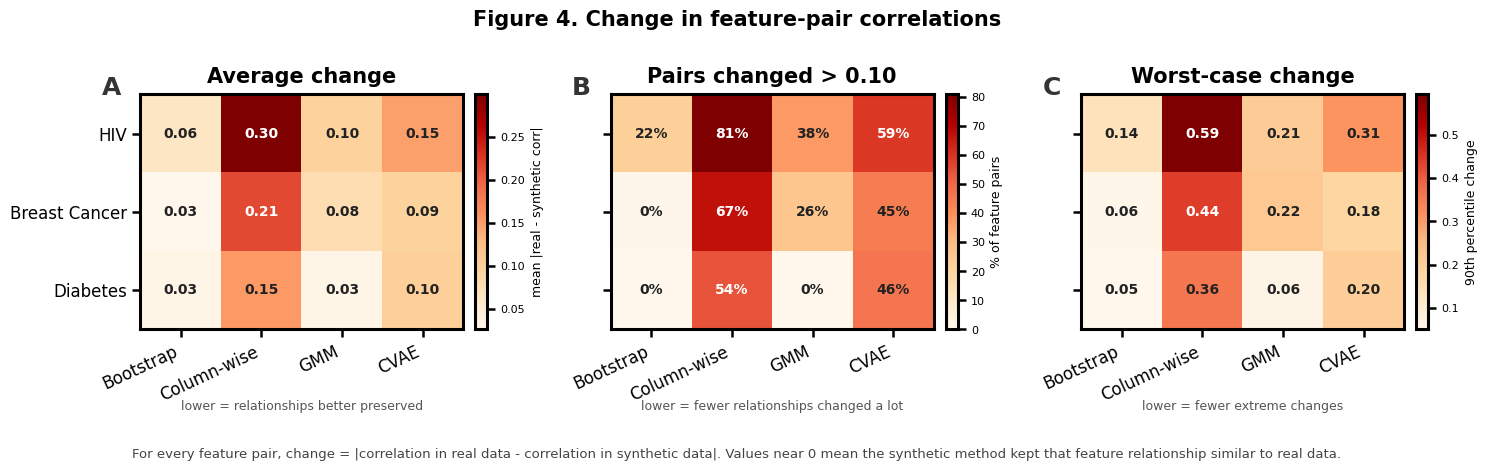

In [72]:
corr_summary, feature_corr_change, changed_corr_pairs = get_correlation_preservation(force=False)
display(corr_summary.sort_values(["dataset", "method"]))
fig4_summary = plot_figure4_correlation_change(corr_summary)

# Diagnostic details, not intended as the main figure: which features/pairs drive the change?
top_feature_change_table = make_top_feature_change_table(feature_corr_change, top_n=5)
top_changed_pair_table = make_top_changed_pair_table(changed_corr_pairs, top_n=5)
display(top_feature_change_table)
display(top_changed_pair_table)


## Figure 5: Noise Sensitivity

Repeated here from the outline notebook so this revision notebook can generate the full figure set in one place. Synthetic data are perturbed by increasing Gaussian noise, and RF real-vs-synthetic separability is recomputed across datasets and generators.


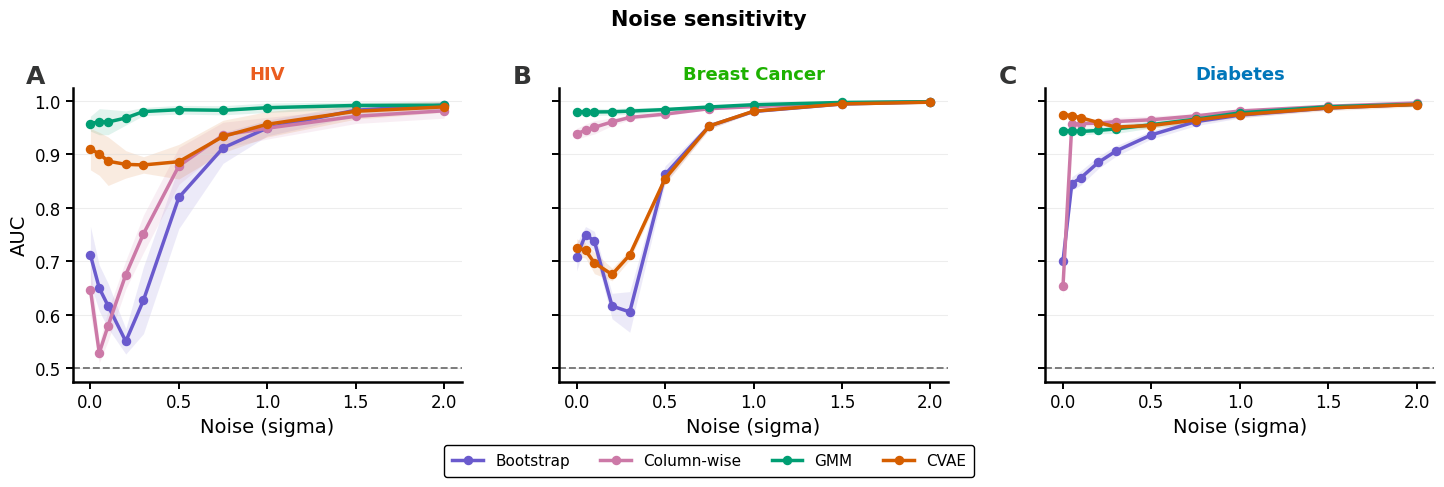

In [73]:
def stratified_subsample(X, y, n0, n1, seed=SEED):
    rng = np.random.default_rng(seed)
    idx0 = np.where(y == 0)[0]
    idx1 = np.where(y == 1)[0]
    take0 = rng.choice(idx0, size=max(1, min(n0, len(idx0))), replace=False)
    take1 = rng.choice(idx1, size=max(1, min(n1, len(idx1))), replace=False)
    idx = np.r_[take0, take1]
    rng.shuffle(idx)
    return X[idx], y[idx]


def compute_noise_sensitivity(datasets, seed=SEED, repeats=NOISE_REPEATS, sigmas=PROBE_SIGMAS, frac=NOISE_FRAC, cvae_epochs=CVAE_EPOCHS):
    rows = []
    for ds in DATASET_ORDER:
        data = datasets[ds]
        X = np.asarray(data["X"], dtype=np.float32)
        y = np.asarray(data["y"], dtype=int)
        n0 = max(2, int((y == 0).sum() * frac))
        n1 = max(2, int((y == 1).sum() * frac))
        X_sub, y_sub = stratified_subsample(X, y, n0, n1, seed=seed)
        stds = X_sub.std(axis=0)
        stds = np.where(stds == 0, 1.0, stds)
        feat_cols = [f"f{i}" for i in range(X_sub.shape[1])]
        print(f"[noise] training CVAE for {ds}")
        state = train_cvae(X_sub, y_sub, cfg=Config(seed=seed, epochs=cvae_epochs, batch_size=32), verbose=False)
        generators = {
            "Bootstrap": lambda s: sample_bootstrap(X_sub, y_sub, n0, n1, seed=s),
            "Column-wise": lambda s: sample_columnwise(X_sub, y_sub, n0, n1, seed=s),
            "GMM": lambda s: sample_gmm(X_sub, y_sub, n0, n1, seed=s),
            "CVAE": lambda s: sample_trained_cvae(state, n0, n1, seed=s),
        }
        for method, gen in generators.items():
            for sigma in sigmas:
                vals = []
                for r in range(repeats):
                    rep_seed = seed + r
                    X_syn, _ = gen(rep_seed)
                    X_syn = np.asarray(X_syn, dtype=np.float64)
                    if sigma > 0:
                        rng = np.random.default_rng(rep_seed + 500)
                        X_syn = X_syn + rng.standard_normal(X_syn.shape) * stds * sigma
                    real_df = pd.DataFrame(X_sub, columns=feat_cols)
                    real_df["target"] = 1
                    syn_df = pd.DataFrame(X_syn, columns=feat_cols)
                    syn_df["target"] = 0
                    combined = pd.concat([real_df, syn_df], ignore_index=True)
                    avg, _, _ = RFWrapper.from_combined(combined)
                    vals.append(max(float(avg), 1.0 - float(avg)))
                rows.append({"dataset": ds, "method": method, "sigma": sigma,
                             "sep_mean": float(np.mean(vals)), "sep_sd": float(np.std(vals)),
                             "sep_values": [float(v) for v in vals]})
                print(f"[noise] {ds} {method} sigma={sigma}")
    return pd.DataFrame(rows)


def get_noise_sensitivity(force=False):
    cached = None if force else _read_cache("noise_df")
    if cached is not None:
        return cached
    result = compute_noise_sensitivity(datasets)
    return _write_cache("noise_df", result)


def noise_axis_position(sigma, expand_until=0.5, expand_factor=2.4):
    sigma = np.asarray(sigma, dtype=float)
    return np.where(sigma <= expand_until, sigma * expand_factor, expand_until * expand_factor + (sigma - expand_until))


def plot_figure5_noise(noise_df):
    fig, axes = plt.subplots(1, 3, figsize=(14.8, 4.9), sharey=True, constrained_layout=False)
    legend_handles = []
    tick_sigmas = np.asarray(sorted(noise_df["sigma"].unique()), dtype=float)
    tick_sigmas = tick_sigmas[np.isin(tick_sigmas, [0, 0.1, 0.2, 0.3, 0.5, 1.0, 1.5, 2.0])]
    tick_positions = noise_axis_position(tick_sigmas)
    tick_labels = [f"{s:g}" for s in tick_sigmas]

    for ax, ds, panel in zip(axes, DATASET_ORDER, ["A", "B", "C"]):
        sub = noise_df[noise_df["dataset"] == ds]
        for method in METHOD_ORDER:
            m = sub[sub["method"] == method].sort_values("sigma")
            if m.empty:
                continue
            x = noise_axis_position(m["sigma"])
            line, = ax.plot(x, m["sep_mean"], marker="o", color=METHOD_COLORS[method], label=method,
                            linewidth=2.5, markersize=5.8)
            ax.fill_between(x, m["sep_mean"] - m["sep_sd"], m["sep_mean"] + m["sep_sd"],
                            color=METHOD_COLORS[method], alpha=0.12, linewidth=0)
            if ax is axes[0]:
                legend_handles.append(line)
        ax.axhline(0.5, color="#777777", linestyle="--", linewidth=1.35)
        ax.axvline(noise_axis_position(0.5), color="#BBBBBB", linestyle=":", linewidth=1.0, zorder=0)
        ax.set_title(ds, color=DATASET_COLORS[ds], weight="semibold", fontsize=13)
        ax.set_xlabel("Noise (sigma)")
        ax.set_xticks(tick_positions)
        ax.set_xticklabels(tick_labels)
        ax.set_xlim(noise_axis_position(0) - 0.05, noise_axis_position(float(np.max(noise_df["sigma"]))) + 0.08)
        clean_axis(ax, grid_axis="y")
        ax.spines["left"].set_linewidth(1.8)
        ax.spines["bottom"].set_linewidth(1.8)
        ax.tick_params(width=1.4, length=5)
        add_panel_label(ax, panel)
    axes[0].set_ylabel("AUC")
    fig.legend(legend_handles, METHOD_ORDER, loc="lower center", bbox_to_anchor=(0.5, 0.01), ncol=len(METHOD_ORDER),
               frameon=True, facecolor="white", edgecolor="black", framealpha=1.0, borderpad=0.55)
    fig.suptitle("Noise sensitivity", y=0.98, fontsize=15, weight="semibold")
    fig.text(0.5, 0.075, "The x-axis expands 0-0.5 to show the low-noise region more clearly; tick labels show original sigma values.",
             ha="center", fontsize=9.0, color="#444444")
    fig.subplots_adjust(left=0.07, right=0.99, top=0.82, bottom=0.26, wspace=0.25)
    return fig


noise_df = get_noise_sensitivity(force=False)
fig5_noise = plot_figure5_noise(noise_df)


## Figure 6: Single Combined Reverse-Ablation Figure

This uses the all-dataset A-C function added to the outline notebook, and keeps the x-axis as percentage of top discriminator-ranked features removed so datasets with different numbers of features are comparable.


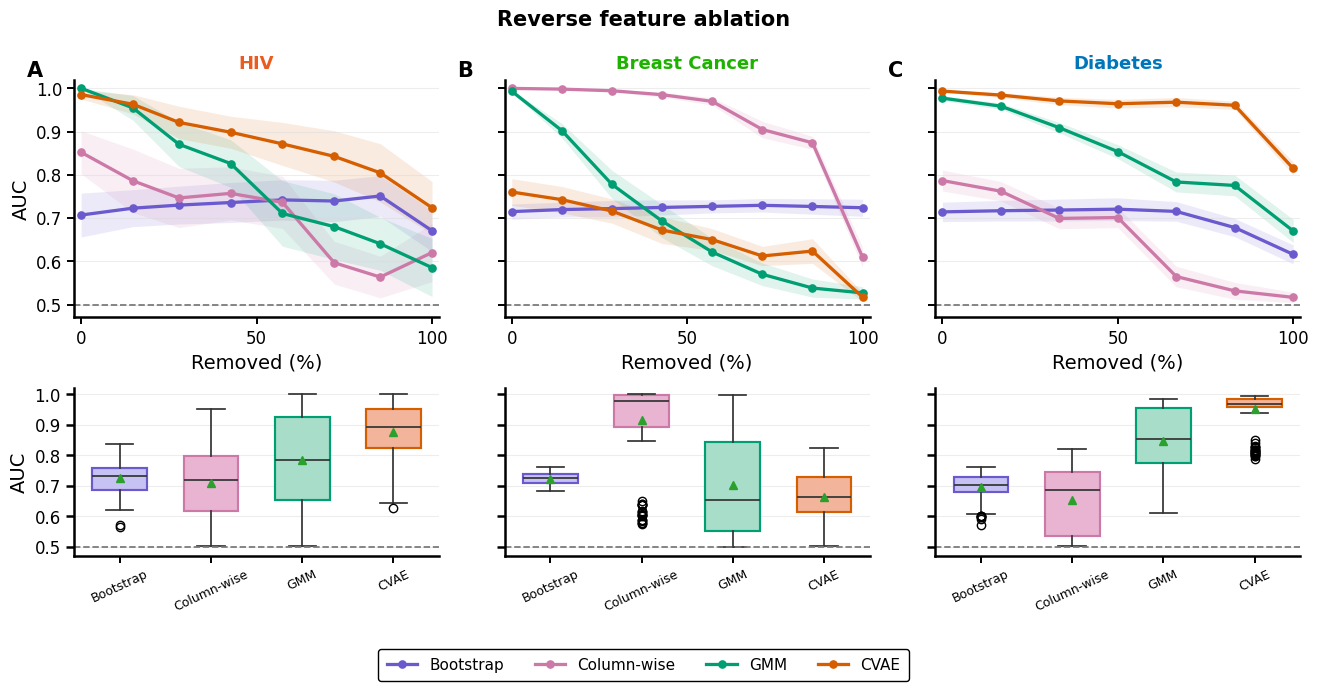

In [74]:
def _flat_values(series):
    vals = []
    for item in series:
        vals.extend(item if isinstance(item, (list, tuple, np.ndarray)) else [item])
    return np.asarray(vals, dtype=float)


def plot_figure6_ablation_all_datasets(ablation_df):
    fig = plt.figure(figsize=(13.4, 7.0), constrained_layout=False)
    gs = fig.add_gridspec(2, len(DATASET_ORDER), height_ratios=[1.35, 0.95])
    curve_axes = [fig.add_subplot(gs[0, i]) for i in range(len(DATASET_ORDER))]
    box_axes = [fig.add_subplot(gs[1, i], sharey=curve_axes[0]) for i in range(len(DATASET_ORDER))]

    legend_handles = []
    for panel_idx, (ax_curve, ax_box, ds) in enumerate(zip(curve_axes, box_axes, DATASET_ORDER)):
        sub = ablation_df[ablation_df["dataset"] == ds]
        box_values, box_labels = [], []
        if sub.empty:
            ax_curve.set_visible(False)
            ax_box.set_visible(False)
            continue

        for method in METHOD_ORDER:
            m = sub[sub["method"] == method].sort_values("n_features_removed")
            if m.empty:
                continue
            n_removed = m["n_features_removed"]
            line, = ax_curve.plot(n_removed, m["auc_mean"], color=METHOD_COLORS[method], marker="o",
                                  linewidth=2.35, markersize=5.2, label=method)
            ax_curve.fill_between(n_removed, m["auc_mean"] - m["auc_sd"], m["auc_mean"] + m["auc_sd"],
                                  color=METHOD_COLORS[method], alpha=0.12, linewidth=0)
            if panel_idx == 0:
                legend_handles.append(line)
            box_values.append(_flat_values(m["auc_values"]))
            box_labels.append(method)

        ax_curve.axhline(0.5, color="#777777", linestyle="--", linewidth=1.25)
        ax_curve.set_title(ds, color=DATASET_COLORS[ds], weight="semibold", pad=8, fontsize=13)
        ax_curve.text(-0.13, 1.08, chr(ord("A") + panel_idx), transform=ax_curve.transAxes,
                      fontsize=15, weight="bold", va="top", ha="left")
        max_removed = int(sub["n_features_removed"].max())
        ax_curve.set_xlim(-1, max_removed + 1)
        ax_curve.set_xlabel("Features removed")
        clean_axis(ax_curve, grid_axis="y")
        ax_curve.spines["left"].set_linewidth(1.8)
        ax_curve.spines["bottom"].set_linewidth(1.8)
        ax_curve.tick_params(width=1.4, length=5)

        bp = ax_box.boxplot(box_values, tick_labels=box_labels, patch_artist=True, showmeans=True, widths=0.60)
        for patch, method in zip(bp["boxes"], box_labels):
            patch.set_facecolor(METHOD_PASTELS[method])
            patch.set_edgecolor(METHOD_COLORS[method])
            patch.set_linewidth(1.55)
        for key in ["whiskers", "caps", "medians", "means"]:
            for artist in bp.get(key, []):
                artist.set_color(NEUTRAL)
                artist.set_linewidth(1.25)
        ax_box.axhline(0.5, color="#777777", linestyle="--", linewidth=1.25)
        ax_box.tick_params(axis="x", rotation=25, labelsize=9.0, width=1.4, length=5)
        clean_axis(ax_box, grid_axis="y")
        ax_box.spines["left"].set_linewidth(1.8)
        ax_box.spines["bottom"].set_linewidth(1.8)

    curve_axes[0].set_ylabel("AUC")
    box_axes[0].set_ylabel("AUC")
    for ax in curve_axes[1:] + box_axes[1:]:
        ax.tick_params(labelleft=False)

    y_values = []
    for _, row in ablation_df.iterrows():
        y_values.extend([row["auc_mean"] - row["auc_sd"], row["auc_mean"] + row["auc_sd"]])
        y_values.extend(row.get("auc_values", []))
    y_min = max(0.45, np.nanmin(y_values) - 0.03)
    y_max = min(1.02, np.nanmax(y_values) + 0.03)
    for ax in curve_axes + box_axes:
        if ax.get_visible():
            ax.set_ylim(y_min, y_max)

    handles = legend_handles[:len(METHOD_ORDER)]
    fig.legend(handles, [h.get_label() for h in handles], loc="lower center",
               bbox_to_anchor=(0.5, 0.01), ncol=len(handles), frameon=True,
               facecolor="white", edgecolor="black", framealpha=1.0, borderpad=0.55)
    fig.suptitle("Reverse feature ablation", y=0.98, fontsize=15, weight="semibold")

    fig.subplots_adjust(left=0.075, right=0.99, top=0.88, bottom=0.20, wspace=0.18, hspace=0.35)
    return fig


ablation_df = get_reverse_ablation(force=False)
fig6_ac = plot_figure6_ablation_all_datasets(ablation_df)


## Export Helpers

Exports are intentionally explicit so we do not overwrite manuscript files by accident.


In [75]:
EXPORT_DIR = repo_root / "data_synthesis" / "notebooks" / "revision_exports"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# Uncomment after running the corresponding figure cells.
# fig2_6.savefig(EXPORT_DIR / "figure2_six_panel_revision.png", dpi=300, bbox_inches="tight")
# fig2_9.savefig(EXPORT_DIR / "figure2_nine_panel_revision.png", dpi=300, bbox_inches="tight")
# fig4_summary.savefig(EXPORT_DIR / "figure4_correlation_summary_revision.png", dpi=300, bbox_inches="tight")
# fig5_noise.savefig(EXPORT_DIR / "figure5_noise_revision.png", dpi=300, bbox_inches="tight")
# fig6_ac.savefig(EXPORT_DIR / "figure6_ablation_all_datasets_revision.png", dpi=300, bbox_inches="tight")

SCHEMATIC_PPTX = EXPORT_DIR / "schematic_workflow_editable.pptx"
SCHEMATIC_PPTX


WindowsPath('c:/Users/tonyt/Desktop/distinguishable_data/data_synthesis/notebooks/revision_exports/schematic_workflow_editable.pptx')

## Schematic Edit Note

The schematic in `make_main_figures_outline_v2.ipynb` appears to be generated with Matplotlib patches and text, not GPT image generation and not PowerPoint/Keynote. I created editable PowerPoint versions using native PPT shapes at:

`data_synthesis/notebooks/revision_exports/schematic_workflow_editable.pptx`

`data_synthesis/notebooks/revision_exports/schematic_workflow_editable_v2.pptx`

`data_synthesis/notebooks/revision_exports/schematic_workflow_editable_v3.pptx`

Use the v3 file first: it fixes the Evaluation hierarchy coloring, makes Structure look like the correlation heatmap from the notebook, and restores the AUC / utility panel to a ROC-plus-boxplot summary closer to the original schematic. All section boxes, text, arrows, markers, and mini-panels are editable PowerPoint objects. `python-pptx` is included in the project dependencies, so we can keep iterating the schematic as a PPT source if that is easier for font-size and flow tuning.
